# Instructions for Running Code
Run all code cells in the order that you see them here, and markdown cells contain section headers, analysis, and other important observations.

# Competition 1: Beer Quality Prediction 🍺

This notebook provides starter code for the Beer Quality Prediction competition. For full instructions, problem statement, and grading criteria, please refer to the **README.md** file.

**Quick Summary**: You will build a classification model to predict beer quality (scores 1-10) based on chemical properties. Submit your predictions to [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Import Dependencies

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Explore Data

In [2]:
# Load the training data and set ; as the delimiter 
train_df = pd.read_csv('data/train.csv', delimiter=';', index_col="id")

# Training Data 
print(f"Training data shape: {train_df.shape}")
print(f"Number of samples (n): {train_df.shape[0]}")
print(f"Number of features (d): {train_df.shape[1] - 1}")  # Subtract 1 for target column
print(f"Columns: {list(train_df.columns)}")
print("\nFirst few rows:")
print(train_df.head())


Training data shape: (4469, 14)
Number of samples (n): 4469
Number of features (d): 13
Columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

First few rows:
   beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
id                                                                   
0        Pale           7.997                   0.446        0.280   
1        Pale           6.906                   0.222        0.303   
2       Brown           7.183                   0.636        0.071   
3        Pale           6.403                   0.242        0.260   
4       Brown           7.917                   0.182        0.347   

    final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity  \
id                                                                        
0          10.803   

In [3]:
# Check data types and basic information 
print("\nData types and info for train df:")
print(train_df.info())


Data types and info for train df:
<class 'pandas.core.frame.DataFrame'>
Index: 4469 entries, 0 to 4468
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beer_style              4469 non-null   object 
 1   bitterness_IBU          4469 non-null   float64
 2   diacetyl_concentration  4469 non-null   float64
 3   lactic_acid             4469 non-null   float64
 4   final_gravity           4469 non-null   float64
 5   sodium                  4469 non-null   float64
 6   free_CO2                4469 non-null   float64
 7   dissolved_oxygen        4469 non-null   float64
 8   original_gravity        4469 non-null   float64
 9   pH                      4469 non-null   float64
 10  gypsum_level            4469 non-null   float64
 11  alcohol_ABV             4469 non-null   float64
 12  fermentation_strength   4469 non-null   float64
 13  quality                 4469 non-null   int64  
dtypes: float64

In [4]:
# Reading test dataframe as a csv file  
test_df = pd.read_csv('data/test.csv', delimiter=';', index_col="id")

# Test Data 
print(f"Test data shape: {test_df.shape}")
print(f"Number of samples (n): {test_df.shape[0]}")
print(f"Columns: {list(test_df.columns)}")
print("\nFirst few rows:")
print(test_df.head())

Test data shape: (511, 13)
Number of samples (n): 511
Columns: ['beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength']

First few rows:
   beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
id                                                                   
0      Golden           7.904                   0.419        0.501   
1        Pale           6.317                   0.223        0.575   
2      Golden           5.483                   0.347        0.254   
3        Pale           5.183                   0.515        0.166   
4        Dark          13.505                   0.527        0.792   

    final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity  \
id                                                                        
0           8.200   0.074    31.994           163.998           

In [5]:
# Check data types and basic info
print("\nData types and info for test df:")
print(test_df.info())


Data types and info for test df:
<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 510
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   beer_style              511 non-null    object 
 1   bitterness_IBU          511 non-null    float64
 2   diacetyl_concentration  511 non-null    float64
 3   lactic_acid             511 non-null    float64
 4   final_gravity           511 non-null    float64
 5   sodium                  511 non-null    float64
 6   free_CO2                511 non-null    float64
 7   dissolved_oxygen        511 non-null    float64
 8   original_gravity        511 non-null    float64
 9   pH                      511 non-null    float64
 10  gypsum_level            511 non-null    float64
 11  alcohol_ABV             511 non-null    float64
 12  fermentation_strength   511 non-null    float64
dtypes: float64(12), object(1)
memory usage: 55.9+ KB
None


In [6]:
## Data Exploration and Visualization Continued 
# Listing column names for train and test data 

# Printing summary statistics 
print("\n Summary Statistics")
display(train_df.describe())

# Data Type per feature 
print("\n Data Type per feature")
print(train_df.dtypes.value_counts)



 Summary Statistics


,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
count,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000
mean,7.235609,0.338640,0.317996,5.506593,0.055572,30.744267,116.383056,0.994855,3.217238,0.528450,4.986386,9.478692,5.811815
std,1.296424,0.163701,0.145221,4.741626,0.033916,18.011711,56.441889,0.010509,0.161431,0.143315,0.560061,0.892119,0.838949
min,3.804000,0.064000,-0.022000,0.596000,-0.004000,0.998000,5.991000,0.957000,2.723000,0.216000,3.816000,7.429000,3.000000
25%,6.410000,0.226000,0.245000,1.805000,0.037000,16.999000,78.994000,0.988000,3.107000,0.430000,4.524000,8.778000,5.000000
50%,6.996000,0.293000,0.308000,3.119000,0.049000,29.001000,118.997000,0.995000,3.205000,0.506000,4.904000,9.348000,6.000000
75%,7.697000,0.404000,0.393000,8.196000,0.067000,41.984000,156.000000,1.002000,3.320000,0.598000,5.382000,10.109000,6.000000
max,15.885000,1.572000,1.672000,31.612000,0.603000,288.995000,440.004000,1.032000,4.006000,1.989000,7.096000,12.648000,9.000000



 Data Type per feature
<bound method IndexOpsMixin.value_counts of beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object>


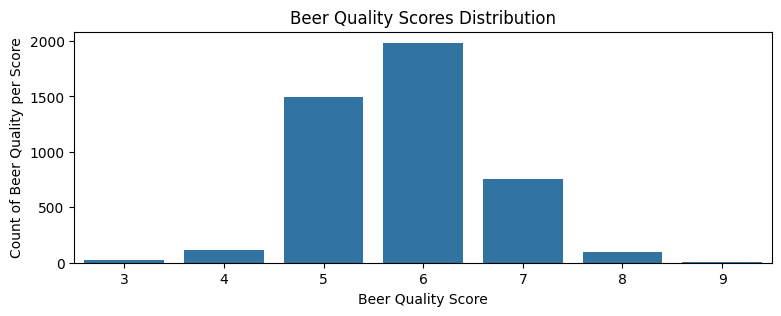

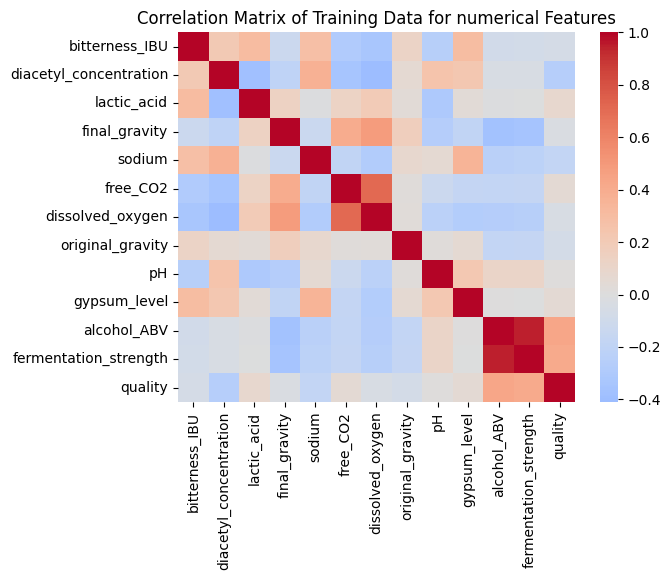

In [7]:
## Data Visualization and Exploring
## Visualizing Target variables
plt.figure(figsize=(9,3))
sns.countplot(x="quality",data=train_df)
plt.title("Beer Quality Scores Distribution")
plt.xlabel("Beer Quality Score")
plt.ylabel("Count of Beer Quality per Score")
plt.show()

## Plotting Correlation Matrix for numerical Features 
features = train_df.select_dtypes(include=["float64", "int64"]).columns
sns.heatmap(train_df[features].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Training Data for numerical Features")
plt.show()

**Analysis**

The bar chart indicates that quality is highly centered around scores 5, 6, and to a lesser extent 7. Scores 1 and 2 are not present in the data. This indicates severe class imbalance which may prove problematic for accuracy in the evaluated model. 

The correlation matrix indicates that alcohol_ABV and fermentation_strength are highly correlated together and the feature pH is poorly correlated with the target variable quality. This could give us some good insight into how I could perform feature engineering later on. 

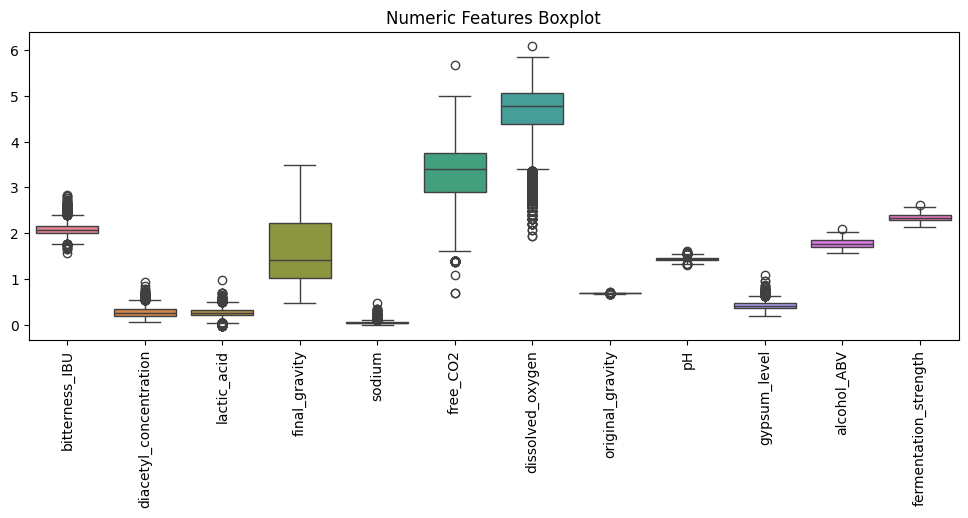

In [8]:
## Detecting Outliers for feature columns using a box plot 
plt.figure(figsize=(12,4))
## Applying log transform to features to make the scale smaller and easier to read 
sns.boxplot(data=np.log1p(train_df[features.drop(["quality"], errors='ignore')]))
plt.xticks(rotation=90)
plt.title("Numeric Features Boxplot")
plt.show()

**Analysis** 

Boxplot shows outliers for certain numeric features that we can remove later through feature engineering. Outliers can skew accuracy of data. 

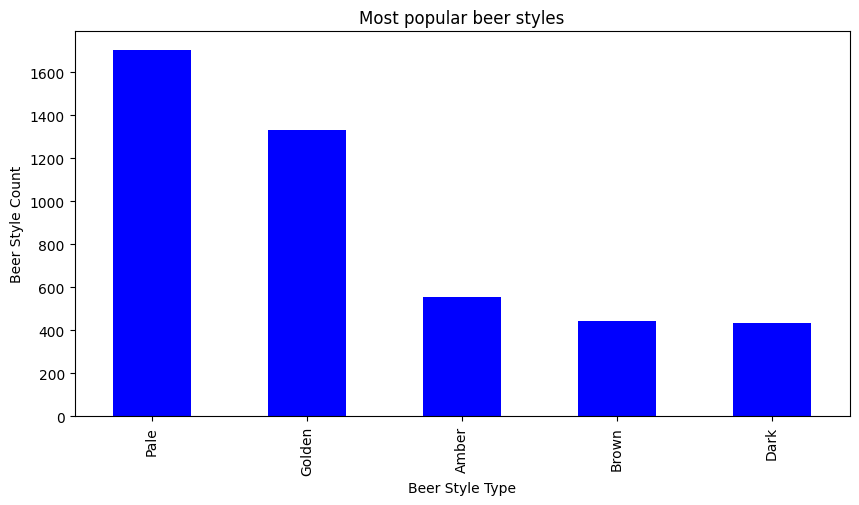

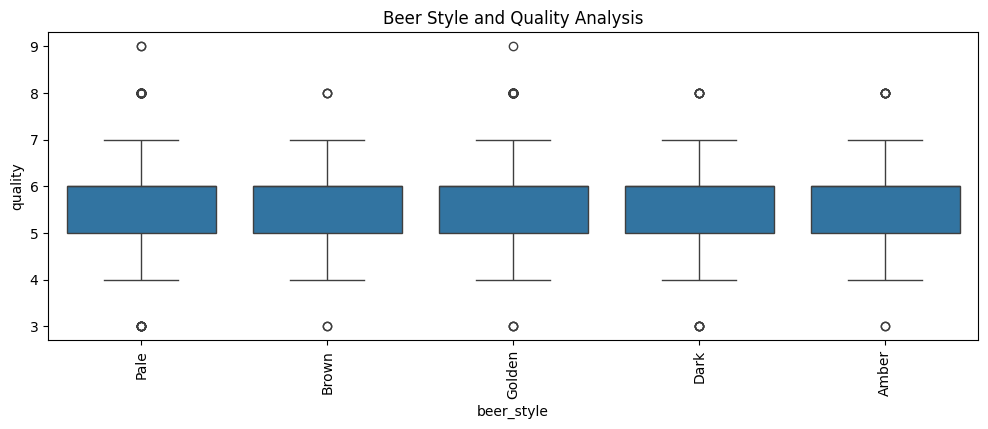

In [9]:
## Analyzing Categorial feature with bar chart - Beer Style column 
plt.figure(figsize=(10,5))
train_df["beer_style"].value_counts().head().plot(kind="bar", color="blue")
plt.title("Most popular beer styles")
plt.xlabel("Beer Style Type")
plt.ylabel("Beer Style Count")
plt.show()

## Analyzing Beer Stlye relationship with Target 
plt.figure(figsize=(12,4))
sns.boxplot(x="beer_style", y="quality", data=train_df)
plt.xticks(rotation=90)
plt.title("Beer Style and Quality Analysis")
plt.show()

**Analysis**

Beer style is predominantly dominated by Pale and Golden as the most popular styles within the data set. However, all styles have qualities largely ranging from 4 to 7 with 5 and 6 being the most common quality scores. This reiterates that 5 and 6 are the most popular quality scores in the data set and should be remembered in model evaluation due to the effects of class imbalances. 

## Data Preprocessing

Implement your preprocessing pipeline (see README.md for suggestions).

In [10]:
# First copy the data frames to avoid modifying the original data frames
df_train = train_df.copy()
df_test = test_df.copy()

# Investigate missing values
print("Investigating the missing values before imputation.")
print(train_df.isnull().sum().sort_values(ascending=False))

# Fill numeric columns if missing values are present 
# Identify numeric columns (exclude 'quality' if present)
numeric_cols = [col for col in df_train.select_dtypes(include=["float64", "int64"]).columns if col != "quality"]

# Filling column in na/missing values with median ones 
for col in numeric_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())
    df_test[col] = df_test[col].fillna(df_train[col].median())

# Fill categorical column with mode value
df_train["beer_style"] = df_train["beer_style"].fillna(df_train["beer_style"].mode()[0])
df_test["beer_style"] = df_test["beer_style"].fillna(df_train["beer_style"].mode()[0])

# Print results
print("\n Missing values after imputations performed for Training data:")
print(df_train.isnull().sum().sum())

print("\n Missing values after imputations performed for Testing data:")
print(df_test.isnull().sum().sum())











Investigating the missing values before imputation.
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

 Missing values after imputations performed for Training data:
0

 Missing values after imputations performed for Testing data:
0


In [11]:
## Removing outlying data based on summary statistics results and boxplot distributions
# Outlier clipping per feature distribution
for col in numeric_cols:
    # Within free_CO2, dissolved_oxygen, and final_gravity column calculating the 5th and 95th percentile 
    # Given these columns are less correlated with quality (target variable)
    # I decided to remove a greater range of outliers as impact to model performance will likely be minimal
    if col in ['free_CO2', 'dissolved_oxygen', 'final_gravity']:
        lower, upper = np.percentile(df_train[col], [5, 95])
        # Calculating the 1st and 99th percentile columns for alcohol_ABV and fermentation_strength
        # Given these columns are more correlated with quality, I decided to be more conservative in the range of outliers removed
        # Removing too many points could negatively impact model performance 
    elif col in ['alcohol_ABV', 'fermentation_strength']:
        lower, upper = np.percentile(df_train[col], [1, 99])
    else:
        # For all other columns, calculate the 2nd and 98th percentile column
        lower, upper = np.percentile(df_train[col], [2, 98])
    # Removing these outlier columns with clip 
    df_train[col] = np.clip(df_train[col], lower, upper)


**Analysis**

Filling in missing values for both numeric and categorical columns with median and mode respectively. Even though analysis reveals that the data set contains no missing values, the code is now set up to process any future data set with missing values. 

Moreover, we remove outliers from numerical columns to prevent any distorted impact on model evaluations that could hinder performance. Based on the earlier boxplot of numerical features, we remove all points below the 5th and above the 95th percentile for free_CO2, dissolved_oxygen, and final_gravity. as well as remove all points below the 1st and above the 99th percentile for alcohol_ABV and fermentation_strength. All other columns have outliers below the 2nd and above the 98th percentile removed. 

In [12]:
## Correlation:
## Printing the Top Correlated Features with quality 
correlation = df_train.drop(columns=["beer_style"]).corr()["quality"].sort_values(ascending=False)
print("\nTop Correlated Features: ")
print(correlation.head(15))

# Seeing relationship between quality and beer style
print("\nBeer Style and Quality: ")
quality_bstyle = df_train.groupby('beer_style')['quality'].mean().sort_values(ascending=False)
print(quality_bstyle)


Top Correlated Features: 
quality                   1.000000
alcohol_ABV               0.432202
fermentation_strength     0.414471
lactic_acid               0.089932
free_CO2                  0.074866
gypsum_level              0.057630
pH                        0.010090
final_gravity            -0.020877
dissolved_oxygen         -0.035196
original_gravity         -0.071395
bitterness_IBU           -0.072348
sodium                   -0.209092
diacetyl_concentration   -0.253498
Name: quality, dtype: float64

Beer Style and Quality: 
beer_style
Golden    5.889474
Amber     5.854578
Pale      5.839789
Brown     5.631222
Dark      5.594037
Name: quality, dtype: float64


In [13]:
# Seeing relationship between alcohol ABV and Fermentation Strength 
df_train[["alcohol_ABV", "fermentation_strength"]].corr()


,alcohol_ABV,fermentation_strength
alcohol_ABV,1.000000,0.948021
fermentation_strength,0.948021,1.000000


In [14]:
# Seeing relationship between bitterness IBU and original gravity
df_train[["bitterness_IBU", "original_gravity"]].corr()

,bitterness_IBU,original_gravity
bitterness_IBU,1.000000,0.121832
original_gravity,0.121832,1.000000


In [15]:
# Seeing relationship between lactic acid, gypsum levels, and free CO2
df_train[["lactic_acid", "gypsum_level", "free_CO2"]].corr()

,lactic_acid,gypsum_level,free_CO2
lactic_acid,1.000000,0.029526,0.150991
gypsum_level,0.029526,1.000000,-0.196248
free_CO2,0.150991,-0.196248,1.000000


In [16]:
# Feature Engineering (adding and removing unnecessary columns)
import numpy as np
import pandas as pd

# Copying df_train and df_test before feature engineering is applied to use in a downstream experiment 
df_train_v2 = df_train.copy()
df_test_v2 = df_test.copy() 

df_train['alcohol_efficiency'] = df_train['alcohol_ABV'] / (df_train['fermentation_strength'] + 1e-6)
df_test['alcohol_efficiency'] = df_test['alcohol_ABV'] / (df_test['fermentation_strength'] + 1e-6)

# Dropping Fermentation strength as it is highly correlated with alcohol_ABV and can be removed
# Also dropping pH as the column is weakly correlated with quality
df_train = df_train.drop(columns=['pH', 'fermentation_strength'])
df_test = df_test.drop(columns=['pH', 'fermentation_strength'])

print("Added engineered features: alcohol efficiency and removed pH column.")


Added engineered features: alcohol efficiency and removed pH column.


In [17]:
## Final Analysis of Results after preprocessing 
print("\nTraining data shape")
print(df_train.shape)
print("\nTraining data types")
print(df_train.dtypes)
print("\nTest data shape")
print(df_test.shape)


Training data shape
(4469, 13)

Training data types
beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
gypsum_level              float64
alcohol_ABV               float64
quality                     int64
alcohol_efficiency        float64
dtype: object

Test data shape
(511, 12)


**Analysis**

Results of correlation matrix show that the alcohol_ABV and fermentation_strength are the most correlated (~0.43 and 0.41 respectively) of the feature columns with quality. Furthermore, alcohol_ABV and fermentation_strength are heavily correlated with one another (~0.95). This indicates that the columns encode similar information. Therefore, I removed fermentation_strength as redundant and added in a column, alcohol_efficiency, which is the quotient of alcohol_ABV and fermentation_strength. The column pH is weakly correlated with quality (~0.01) so it encodes largely irrelevant info towards predicting the target variable so can be safely removed. 

## Prepare Training and Validation Data

Split your data into training and validation sets.

In [18]:
## Splitting Data into Train and Test Validation Sets: 
from sklearn.model_selection import train_test_split

# Defining training and validation data
# Importing Label Encoder 
le = LabelEncoder()
# Applying label encoding fit transform on beer style for training 
df_train['beer_style'] = le.fit_transform(df_train['beer_style'])
# Applying label encoding transform to beer style 
df_test['beer_style'] = le.transform(df_test['beer_style'])

rng = np.random.RandomState(2)

# Removing quality column from X as quality is the label
X = df_train.drop(columns="quality")
# Assigning quality to y 
y= df_train["quality"]

# Using train test split to create training and validation sets 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Printing Training and Training and Validation Set Sizes: 
print(f"Training set sizes for X_train (features) are: {X_train.shape[0]}, Training set sizes for y_train (labels): {y_train.shape}")
print(f"Validation set sizes for X_val (features) are:   {X_val.shape[0]}, Training set sizes for y_val (labels):   {y_val.shape}")


Training set sizes for X_train (features) are: 3575, Training set sizes for y_train (labels): (3575,)
Validation set sizes for X_val (features) are:   894, Training set sizes for y_val (labels):   (894,)


In [19]:
# Printing value counts of quality and beer style 
print(y_train.value_counts(normalize=True).sort_index())
print(X_train["beer_style"].value_counts())


quality
3    0.004755
4    0.026014
5    0.334825
6    0.444196
7    0.168951
8    0.020699
9    0.000559
Name: proportion, dtype: float64
beer_style
4    1374
3    1069
0     438
2     351
1     343
Name: count, dtype: int64


## Train Models

Train and compare multiple machine learning models.

In [20]:
# Importing all necessary libraries and functions for Model Training 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import numpy as np

# Define Preprocessors
preprocessor_std = StandardScaler()
preprocessor_nb = MinMaxScaler()

# Define Parameter Grids for different models 
param_grids = {
    # Defining Logistic Regression Hyperparameters
    # Including C, penalty, multi_class, and solver 
    "Logistic Regression": {
        "clf__C": [0.01, 0.02, 0.1],
        "clf__penalty": ["l2"],
        "clf__multi_class": ["multinomial"],  
        "clf__solver": ["lbfgs"],
    },
    # Defining Linear SVM Hyperparameters 
    # Including penalty, C, and loss
    "Linear SVM": {
        "clf__penalty": ["l2"], 
        "clf__C": [0.01, 0.02, 0.1],
        "clf__loss": ["squared_hinge"],
    },
    # Defining Random Forest Hyperparameters 
    # Including n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, bootstrap, and class_weight
    "Random Forest": {
    "clf__n_estimators": [180, 200],     
    "clf__max_depth": [15, 20],          
    "clf__min_samples_split": [3, 4],      
    "clf__min_samples_leaf": [1, 2],       
    "clf__max_features": ["sqrt"],            
    "clf__bootstrap": [True],
    "clf__class_weight": ["balanced_subsample"]
},
    # Defining KNN hyperparameters 
    # This includes n_neighbors, weights, and p
    "KNN": {
        "clf__n_neighbors": [5, 10, 15, 25],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    }
}

# Defining the base models for each model algorithm where we have a pipeline, standardization, polynomial features, and other components
# for each model
base_models = {
    # Logistic Regression Classifier
    "Logistic Regression": Pipeline([("power", PowerTransformer(method='yeo-johnson')),
        ('preprocess', preprocessor_std),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('clf', LogisticRegression(
            multi_class='multinomial',  # multinomial softmax
            solver='lbfgs',
            max_iter=2000,
            random_state=42
        ))
    ]),
    # Defining Linear SVM Pipeline
    "Linear SVM": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', LinearSVC(max_iter=5000, random_state=42))
    ]),
    # Defining Random Forest Pipeline
    "Random Forest": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', RandomForestClassifier(random_state=42))
    ]),
    # Defining KNN Pipeline
    "KNN": Pipeline([
        ('preprocess', preprocessor_std),
        ('clf', KNeighborsClassifier())
    ]),
    # Defining Gaussian Naive Bayes 
    "Gaussian Naive Bayes": Pipeline([
        ('preprocess', preprocessor_nb),
        ('clf', GaussianNB())
    ]),
    # Defining Complement Naive Bayes
    "Complement Naive Bayes": Pipeline([
        ('preprocess', preprocessor_nb),
        ('clf', ComplementNB())
    ])
}

# Training and Hyperparameter Tuning with Cross-Validation
# Defining Cross Validation with K Fold 5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Defining trained models 
trained_models = {}
# Defining best parameters and scores  
best_params = {}
best_scores = {}

# Iterating over base models 
for name, model in base_models.items():
    # Print statement for Training model 
    print(f"\n Training {name}...")
    # Iterating over the parameter grids 
    if name in param_grids:
        # Creating Grid Search Cross Validation for accuracy 
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            scoring='accuracy',
            cv=cv,
            n_jobs=-1
        )
        # Fitting training data on grid 
        grid.fit(X_train, y_train)
        # Getting the best estimator 
        trained_models[name] = grid.best_estimator_
        # Getting the best parameter name and scores 
        best_params[name] = grid.best_params_
        best_scores[name] = grid.best_score_
        # Printing the best cv accuracy and best parameters amongst the models 
        print(f" Best CV Accuracy for {name}: {grid.best_score_:.4f}")
        print(f"   Best Params: {grid.best_params_}")
    # Otherwise fitting model on X_train and y_train data 
    else:
        model.fit(X_train, y_train)
        trained_models[name] = model
        print(f" Trained {name} with default parameters.")
# Models are now all trained successfully 
print("\n All Models are now trained Successfully!")





 Training Logistic Regression...


C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_1\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 Best CV Accuracy for Logistic Regression: 0.5608
   Best Params: {'clf__C': 0.02, 'clf__multi_class': 'multinomial', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

 Training Linear SVM...


C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_1\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


 Best CV Accuracy for Linear SVM: 0.5522
   Best Params: {'clf__C': 0.1, 'clf__loss': 'squared_hinge', 'clf__penalty': 'l2'}

 Training Random Forest...


C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_1\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


 Best CV Accuracy for Random Forest: 0.6126
   Best Params: {'clf__bootstrap': True, 'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 3, 'clf__n_estimators': 180}

 Training KNN...


C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_1\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


 Best CV Accuracy for KNN: 0.5600
   Best Params: {'clf__n_neighbors': 25, 'clf__p': 1, 'clf__weights': 'distance'}

 Training Gaussian Naive Bayes...
 Trained Gaussian Naive Bayes with default parameters.

 Training Complement Naive Bayes...
 Trained Complement Naive Bayes with default parameters.

 All Models are now trained Successfully!


## Evaluate Models

Analyze your best model's performance (see README.md for evaluation guidelines).


 Evaluating Logistic Regression...

 Performance on Training set for Logistic Regression:
Training Accuracy: 0.5908
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        17
           4       0.67      0.04      0.08        93
           5       0.65      0.63      0.64      1197
           6       0.56      0.73      0.63      1588
           7       0.58      0.31      0.40       604
           8       1.00      0.03      0.05        74
           9       0.00      0.00      0.00         2

    accuracy                           0.59      3575
   macro avg       0.49      0.25      0.26      3575
weighted avg       0.60      0.59      0.57      3575



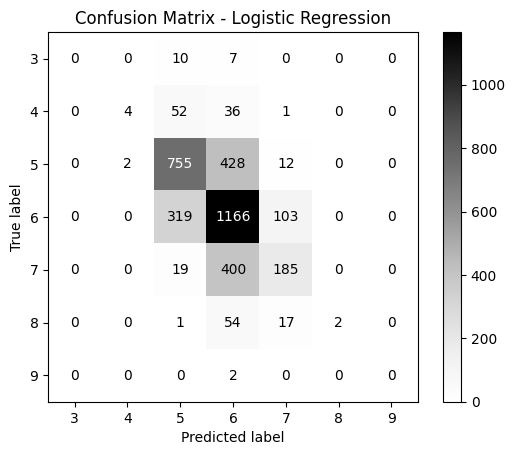


 Validation set performance for Logistic Regression:
Accuracy: 0.5716
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.62      0.63      0.62       299
           6       0.56      0.73      0.63       397
           7       0.46      0.23      0.30       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.57       894
   macro avg       0.23      0.23      0.22       894
weighted avg       0.53      0.57      0.54       894



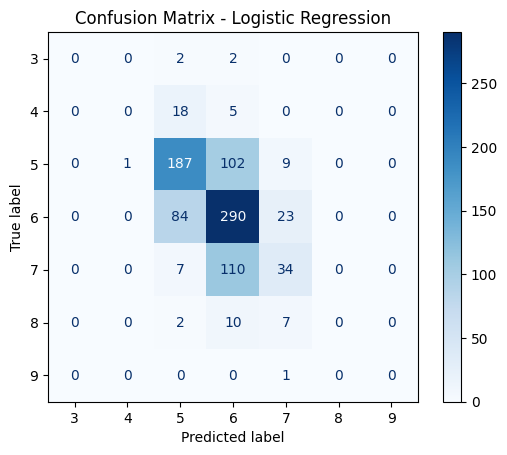


 Evaluating Linear SVM...

 Performance on Training set for Linear SVM:
Training Accuracy: 0.5558
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        17
           4       0.00      0.00      0.00        93
           5       0.62      0.64      0.63      1197
           6       0.52      0.75      0.61      1588
           7       0.66      0.04      0.08       604
           8       0.00      0.00      0.00        74
           9       0.00      0.00      0.00         2

    accuracy                           0.56      3575
   macro avg       0.26      0.21      0.19      3575
weighted avg       0.55      0.56      0.50      3575



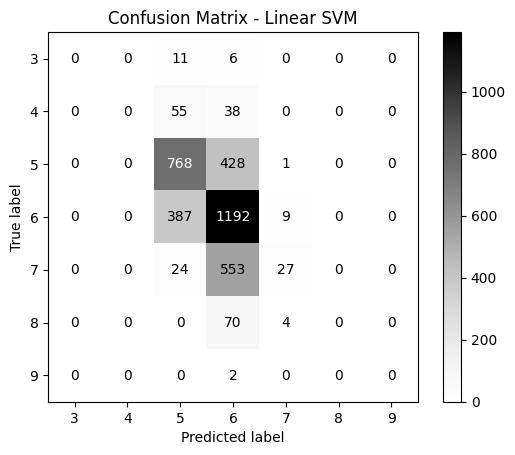


 Validation set performance for Linear SVM:
Accuracy: 0.5291
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.57      0.60      0.58       299
           6       0.51      0.73      0.60       397
           7       0.56      0.03      0.06       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.53       894
   macro avg       0.23      0.19      0.18       894
weighted avg       0.51      0.53      0.47       894



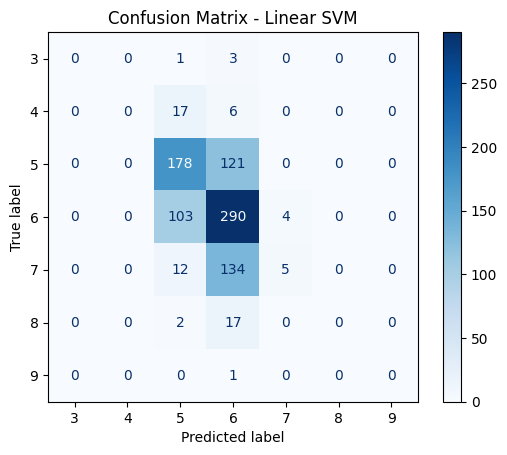


 Evaluating Random Forest...

 Performance on Training set for Random Forest:
Training Accuracy: 0.9933
              precision    recall  f1-score   support

           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        93
           5       0.99      0.99      0.99      1197
           6       1.00      0.99      0.99      1588
           7       0.99      1.00      1.00       604
           8       1.00      1.00      1.00        74
           9       1.00      1.00      1.00         2

    accuracy                           0.99      3575
   macro avg       1.00      1.00      1.00      3575
weighted avg       0.99      0.99      0.99      3575



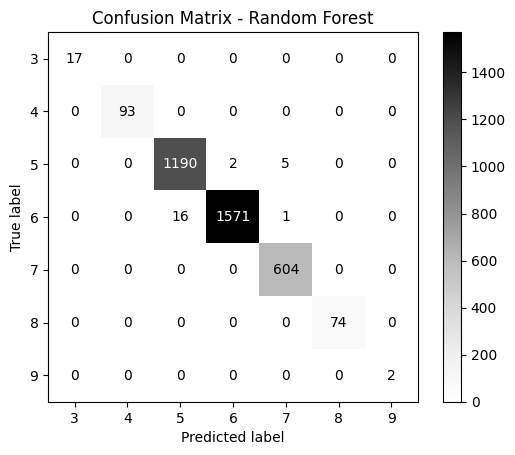


 Validation set performance for Random Forest:
Accuracy: 0.5850
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.62      0.65      0.63       299
           6       0.58      0.70      0.63       397
           7       0.50      0.34      0.41       151
           8       1.00      0.05      0.10        19
           9       0.00      0.00      0.00         1

    accuracy                           0.59       894
   macro avg       0.39      0.25      0.25       894
weighted avg       0.57      0.59      0.56       894



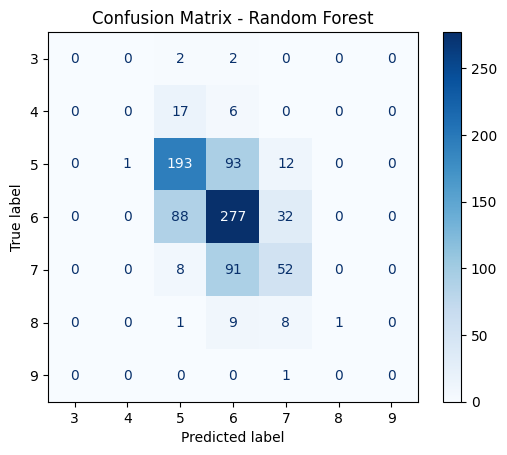


 Evaluating KNN...



 Performance on Training set for KNN:
Training Accuracy: 1.0000
              precision    recall  f1-score   support

           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        93
           5       1.00      1.00      1.00      1197
           6       1.00      1.00      1.00      1588
           7       1.00      1.00      1.00       604
           8       1.00      1.00      1.00        74
           9       1.00      1.00      1.00         2

    accuracy                           1.00      3575
   macro avg       1.00      1.00      1.00      3575
weighted avg       1.00      1.00      1.00      3575



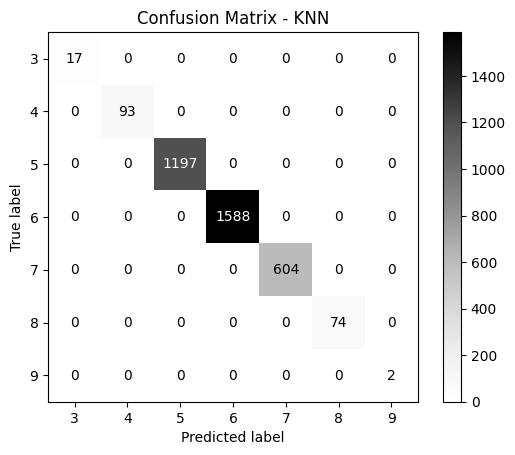


 Validation set performance for KNN:
Accuracy: 0.5694
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.64      0.59      0.61       299
           6       0.55      0.74      0.63       397
           7       0.45      0.26      0.33       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.57       894
   macro avg       0.24      0.23      0.22       894
weighted avg       0.54      0.57      0.54       894



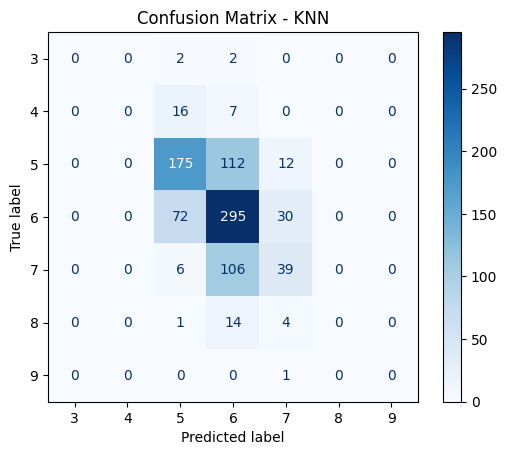


 Evaluating Gaussian Naive Bayes...

 Performance on Training set for Gaussian Naive Bayes:
Training Accuracy: 0.4948
              precision    recall  f1-score   support

           3       0.05      0.18      0.08        17
           4       0.33      0.03      0.06        93
           5       0.55      0.62      0.58      1197
           6       0.52      0.45      0.48      1588
           7       0.39      0.50      0.44       604
           8       0.00      0.00      0.00        74
           9       1.00      1.00      1.00         2

    accuracy                           0.49      3575
   macro avg       0.41      0.40      0.38      3575
weighted avg       0.49      0.49      0.49      3575



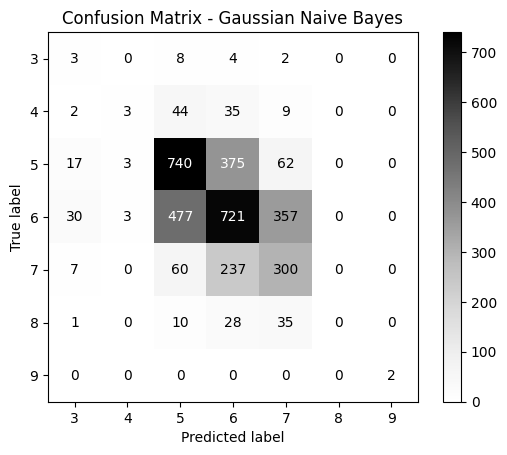


 Validation set performance for Gaussian Naive Bayes:
Accuracy: 0.5022
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.55      0.60      0.57       299
           6       0.54      0.50      0.52       397
           7       0.38      0.47      0.42       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.50       894
   macro avg       0.21      0.22      0.22       894
weighted avg       0.49      0.50      0.49       894



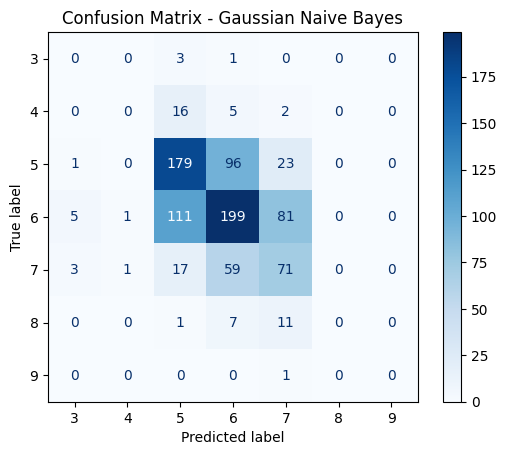


 Evaluating Complement Naive Bayes...

 Performance on Training set for Complement Naive Bayes:
Training Accuracy: 0.4604
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        17
           4       0.00      0.00      0.00        93
           5       0.52      0.75      0.62      1197
           6       0.58      0.22      0.32      1588
           7       0.32      0.67      0.43       604
           8       0.00      0.00      0.00        74
           9       0.00      0.00      0.00         2

    accuracy                           0.46      3575
   macro avg       0.20      0.23      0.20      3575
weighted avg       0.49      0.46      0.42      3575



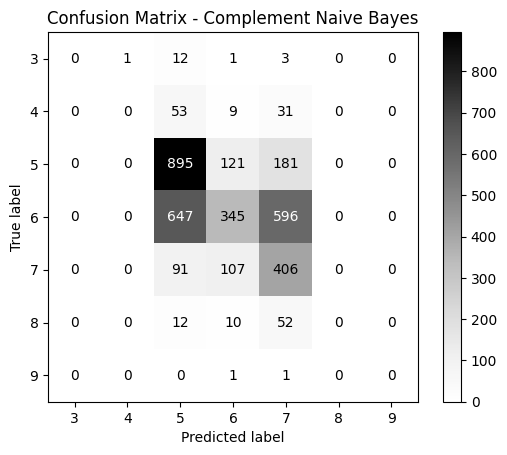


 Validation set performance for Complement Naive Bayes:
Accuracy: 0.4575
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        23
           5       0.51      0.72      0.59       299
           6       0.63      0.23      0.34       397
           7       0.32      0.68      0.43       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.46       894
   macro avg       0.21      0.23      0.19       894
weighted avg       0.50      0.46      0.42       894



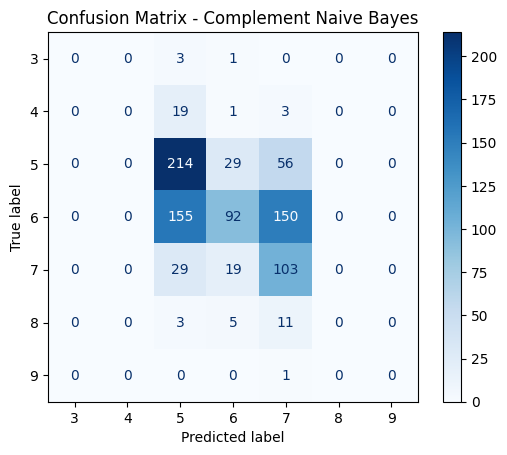


 Training Set Model Performance Summary:
                    Model  Accuracy
3                     KNN  1.000000
2           Random Forest  0.993287
0     Logistic Regression  0.590769
1              Linear SVM  0.555804
4    Gaussian Naive Bayes  0.494825
5  Complement Naive Bayes  0.460420

 Validation Set Model Performance Summary:
                    Model  Accuracy
2           Random Forest  0.585011
0     Logistic Regression  0.571588
3                     KNN  0.569351
1              Linear SVM  0.529083
4    Gaussian Naive Bayes  0.502237
5  Complement Naive Bayes  0.457494


In [21]:
# Importing all relevant libraries for evaluating models 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Defining array of results 
results_train = []
results_val = []

# Iterating over trained_models 
for name, model in trained_models.items():
    # Printing evaluating statement 
    print(f"\n Evaluating {name}...")

    # Predictions on the training data 
    y_pred_train = model.predict(X_train)
    # Obtaining accuracy score of predictions on training data 
    acc_train = accuracy_score(y_train, y_pred_train)
    # Printing performance and accuracy for models on training set
    results_train.append((name, acc_train))
    print(f"\n Performance on Training set for {name}:")
    print(f"Training Accuracy: {acc_train:.4f}")
    print(classification_report(y_train, y_pred_train, zero_division=0))


    # Printing Confusion Matrix for Predicted Models on Training Data
    labels = np.unique(np.concatenate([y_train, y_pred_train]))
    ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_train, labels=labels),
                           display_labels=labels).plot(cmap="Grays")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # Predictions on the Validation Data
    # If Polynomial Regregression in model name, round the predictions to the nearest integer
    if "Polynomial Regression" in name:
        y_pred = np.round(model.predict(X_val)).astype(int)
        y_pred = np.clip(y_pred, y_val.min(), y_val.max()) 
    else:
        y_pred = model.predict(X_val)

    # Defining accuracy score for model's on the validation sets 
    acc = accuracy_score(y_val, y_pred)
    results_val.append((name, acc))
    print(f"\n Validation set performance for {name}:")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_pred, zero_division=0))

    # Printing confusion matrix for model's predictions on the validation set 
    labels = np.unique(np.concatenate([y_val, y_pred]))
    ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred, labels=labels),
                           display_labels=labels).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Summarizing results for validation and training set 
results_train_df = pd.DataFrame(results_train, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
results_val_df = pd.DataFrame(results_val, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
print("\n Training Set Model Performance Summary:")
print(results_train_df)
print("\n Validation Set Model Performance Summary:")
print(results_val_df)



In [22]:
# Investigating Errors on Each Model 
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
import pandas as pd 
import numpy as np 

# Defining Error Array 
error_table = []

# Iterating over name and models in trained_models 
for name, model in trained_models.items():
    print(f"\n Calculating errors for this model {name}...")

    # Errors on Training Set
    y_pred_train = model.predict(X_train)
    # First provide accuracy for training 
    acc_train = accuracy_score(y_train, y_pred_train)
    # Calculating training error
    train_error = 1-acc_train 
    # Calculating mean absolute error 
    train_mae = mean_absolute_error(y_train, y_pred_train)
    # Calculating rmse 
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

    # Errors on the Validation Set
    # If model uses polynomial regression in name, round on predictions for quality to complete integers 
    if "Polynomial Regression" in name:
        y_pred_val = np.round(model.predict(X_val)).astype(int)
        y_pred_val = np.clip(y_pred_val, y_val.min(), y_val.max())
    else:
        y_pred_val = model.predict(X_val)
    
    # Computing accuracy, error, MAE, and rmse on validation set 
    acc_val = accuracy_score(y_val, y_pred_val)
    err_val = 1 - acc_val
    mae_val = mean_absolute_error(y_val, y_pred_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    
    # Appending errors for training and validation set to error table 
    error_table.append({
        "Model": name,
        "Train Accuracy": acc_train,
        "Train Error": train_error,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Accuracy Validation": acc_val,
        "Error Validation": err_val,
        "MAE Validation": mae_val,
        "RMSE Validation": rmse_val
    })
# Printing error table 
error_table_df = pd.DataFrame(error_table).sort_values("Accuracy Validation", ascending=False)
print("\n Summary of Errors across Model")
print(error_table_df)
    




 Calculating errors for this model Logistic Regression...

 Calculating errors for this model Linear SVM...

 Calculating errors for this model Random Forest...



 Calculating errors for this model KNN...



 Calculating errors for this model Gaussian Naive Bayes...

 Calculating errors for this model Complement Naive Bayes...

 Summary of Errors across Model
                    Model  Train Accuracy  Train Error  Train MAE  Train RMSE  \
2           Random Forest        0.993287     0.006713   0.008112    0.104447   
0     Logistic Regression        0.590769     0.409231   0.452028    0.737412   
3                     KNN        1.000000     0.000000   0.000000    0.000000   
1              Linear SVM        0.555804     0.444196   0.488951    0.763503   
4    Gaussian Naive Bayes        0.494825     0.505175   0.603077    0.920322   
5  Complement Naive Bayes        0.460420     0.539580   0.652308    0.952876   

   Accuracy Validation  Error Validation  MAE Validation  RMSE Validation  
2             0.585011          0.414989        0.464206         0.754554  
0             0.571588          0.428412        0.475391         0.760460  
3             0.569351          0.430649        0

In [23]:
## Investigating which features are important for our best model
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

# Defining the best model which is a random forest 
optimal_rf = trained_models["Random Forest"]["clf"]

# Defining significance of best features 
sig_features = optimal_rf.feature_importances_
# Setting up data frame for significant features 
sig_features_df = pd.DataFrame({"Feature": X_train.columns, "Significance": sig_features}).sort_values(by="Significance", ascending=False)

# Printing sig_features_df head
print(sig_features_df.head(14))

                   Feature  Significance
10             alcohol_ABV      0.147260
3              lactic_acid      0.109621
2   diacetyl_concentration      0.097600
6                 free_CO2      0.094180
1           bitterness_IBU      0.087656
5                   sodium      0.085773
4            final_gravity      0.084076
7         dissolved_oxygen      0.074220
9             gypsum_level      0.073951
11      alcohol_efficiency      0.070047
8         original_gravity      0.055028
0               beer_style      0.020589


## Generate Predictions for Kaggle Submission

Create a CSV file with columns: `id` and `quality` (see README.md for format details).

**Generating Kaggle File and Further hyperparameter optimization for Random Forest**

In [24]:
# Random Forest Classifier (GridSearch + Kaggle Submission)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Define pipeline
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Define parameter grid (narrow around the best values)
# Further optimization of Random Forest model
param_grid = {
    "clf__n_estimators": [200, 250, 400],
    "clf__max_depth": [20, 25, 30],
    "clf__min_samples_split": [4, 5, 6],
    "clf__min_samples_leaf": [2, 3, 4],
    "clf__max_features": ["sqrt"],
    "clf__bootstrap": [True],
    "clf__class_weight": ["balanced_subsample"]
}

# Run Grid Search with cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring as accuracy 
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

print("Starting hyperparameter optimization for Random Forest Model...")
grid_search.fit(X_train, y_train)

print("\n These are the Best parameters found:")
print(grid_search.best_params_)
print(f" Best CV Accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model on validation data
best_rf = grid_search.best_estimator_

y_pred_val = best_rf.predict(X_val)
val_acc = accuracy_score(y_val, y_pred_val)

print(f"\n Validation Accuracy (Best RF): {val_acc:.4f}")
print("\nClassification Report (Validation Set):")
print(classification_report(y_val, y_pred_val, zero_division=0))

# Optional: Training accuracy (to check overfitting)
y_pred_train = best_rf.predict(X_train)
train_acc = accuracy_score(y_train, y_pred_train)
print(f"\n Training Accuracy: {train_acc:.4f}")

# Kaggle Submission (Predictions on Test Data)
print("\n Generating Kaggle submission file for Best Random Forest...")
test_predictions = best_rf.predict(df_test)

# Build submission DataFrame
submission = pd.DataFrame({
    "id": df_test.index,
    "quality": test_predictions
})

# Save to CSV
output_filename = "submission_best_random_forest.csv"
submission.to_csv(output_filename, index=False)

print("\n Submission file created successfully!")
print(submission.head())
print(f" File saved as: {output_filename}")


Starting hyperparameter optimization for Random Forest Model...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


C:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_1\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



 These are the Best parameters found:
{'clf__bootstrap': True, 'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 25, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}
 Best CV Accuracy: 0.6095



 Validation Accuracy (Best RF): 0.6063

Classification Report (Validation Set):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.04      0.08        23
           5       0.65      0.65      0.65       299
           6       0.60      0.72      0.65       397
           7       0.54      0.39      0.45       151
           8       1.00      0.05      0.10        19
           9       0.00      0.00      0.00         1

    accuracy                           0.61       894
   macro avg       0.47      0.27      0.28       894
weighted avg       0.61      0.61      0.59       894




 Training Accuracy: 0.9978

 Generating Kaggle submission file for Best Random Forest...



 Submission file created successfully!
   id  quality
0   0        6
1   1        6
2   2        7
3   3        7
4   4        7
 File saved as: submission_best_random_forest.csv


**Evaluating Random Forest Model with Feature Engineering performed post train-test split**

In [25]:
# Performing feature engineering post train test split to test accuracy on Random Forest Model
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

## Splitting Data into Train and Test Validation Sets: 
from sklearn.model_selection import train_test_split
# Defining training and validation data

# Importing Label Encoder 
le = LabelEncoder()
# Applying label encoding fit transform on beer style for training 
df_train_v2['beer_style'] = le.fit_transform(df_train['beer_style'])
# Applying label encoding transform to beer style 
df_test_v2['beer_style'] = le.transform(df_test['beer_style'])

rng = np.random.RandomState(2)

# Removing quality column from X as quality is the label
X_v2 = df_train_v2.drop(columns="quality")
# Assigning quality to y 
y_v2= df_train_v2["quality"]

# Using train test split to create training and validation sets 
X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42, stratify=y)



# Defining alcohol efficiency as the quotient of alcohol_ABV against fermentation_strength as these two features 
# are the most correlated columns with quality 
X_train_v2["alcohol_eff"] = df_train_v2["alcohol_ABV"]/(df_train_v2["fermentation_strength"] + 1e6)
X_val_v2["alcohol_eff"] = df_test_v2["alcohol_ABV"]/(df_test_v2["fermentation_strength"] + 1e6)
df_test_fe = df_test_v2.copy()
df_test_fe["alcohol_eff"] = df_test_fe["alcohol_ABV"]/(df_test_v2["fermentation_strength"] + 1e6)

# Dropping redundant columns 
# pH has a correlation of around 0.01 with quality and fermentation_strength is highly correlated with alcohol_ABV
# fermentation_strength is 0.41 wrp to quality, while alcohol_ABV is 0.43 wrp to quality
# Thus, fermentation_strength can be removed 
X_train_v2 = X_train_v2.drop(columns=["pH", "fermentation_strength"], errors="ignore")
X_val_v2 = X_val_v2.drop(columns=["pH", "fermentation_strength"], errors="ignore")
df_test_fe = df_test_fe.drop(columns=["pH", "fermentation_strength"], errors="ignore")

# Defining random forest model
opt_rf = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(
    n_estimators=400, 
    max_depth=20, 
    min_samples_split=4, 
    min_samples_leaf=2, 
    max_features='sqrt', 
    bootstrap=True, 
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced_subsample')) ])

# Training and evaluating the the Random Forest Model
print("Evaluating the Random Forest Model with feature engineering post train test split: ")
opt_rf.fit(X_train_v2, y_train_v2)
y_pred_v2 = opt_rf.predict(X_val_v2)

# Printing accuracy of model
acc = accuracy_score(y_val_v2, y_pred_v2)
print("Accuracy is: ", acc)
print("\nClassification Report:")
print(classification_report(y_val_v2, y_pred_v2, zero_division=0))

# Generating Kaggle file for the feature engineering performed post train_test split 
print("\n Generating a Kaggle submission file for additional engineering features (rf_additional_feat_eng.csv)...")
predictions_file = opt_rf.predict(df_test_fe)
final_submission = pd.DataFrame({
    "id": df_test.index,         # assumes df_test index matches Kaggle’s "id"
    "quality": predictions_file  # predicted quality values
})

# Final file for Kaggle submission 
output_filename = "rf_additional_feat_eng.csv"
final_submission.to_csv(output_filename, index=False)
print("\n Submission Preview: ")
print(final_submission.head())




Evaluating the Random Forest Model with feature engineering post train test split: 


Accuracy is:  0.5760626398210291

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.04      0.08        23
           5       0.62      0.65      0.63       299
           6       0.55      0.76      0.64       397
           7       0.62      0.14      0.23       151
           8       0.00      0.00      0.00        19
           9       0.00      0.00      0.00         1

    accuracy                           0.58       894
   macro avg       0.33      0.23      0.23       894
weighted avg       0.57      0.58      0.53       894


 Generating a Kaggle submission file for additional engineering features (rf_additional_feat_eng.csv)...



 Submission Preview: 
   id  quality
0   0        6
1   1        6
2   2        7
3   3        7
4   4        6


---
Good luck with the competition! 🍺
